# Task 4.3 — Single Strain HAI Vic B/Austria/1359417/2021 (D28)

**4.3 predict magnitude of antibody response - Vic B/Austria/1359417/2021 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for Vic B/Austria/1359417/2021 at Day 28

---

## Design notes

**y-values:** log2-transformed. Since Spearman only cares about ranking, no inverse transform is needed for evaluation. Metrics (RMSE, MAE, Spearman) are all in log2 space; CSVs use `np.exp2` to output raw titer scale values.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [2]:
STRAIN = 'Vic B/Austria/1359417/2021'
TARGET_COL = f'HAI_{STRAIN}_d28'
AUTO_ML_MAX_RUNTIME_SECONDS = 60 * 10
ONLY_TRANSCRIPTOMICS_PARTICIPANTS = False  # only train on participants with transcriptomics data (warning: small subset)
FORCE_KEEP_TRANSCRIPTOMICS = True  # even if high missing-ness, keep the transcriptomics cols for training
MISSING_THRESHOLD = 0.8  # drop features if missing more than this % of data

In [3]:
CSV_PATH = '../merged_data/combined.csv'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [4]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [5]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 21)


### Preprocessing — target coverage

Only ~920 / 3757 participants have `HAI_Vic B/Austria/1359417/2021_d28`. Two options:
1. **Drop rows without the target** (current approach below) — clean but discards ~75% of the data.
2. **TODO: Borrow from similar strains.** Other Vic B strains (e.g. earlier B/Victoria lineage strains in the same dataset) may carry signal. Could either (a) impute the target from a correlated strain, or (b) train a multi-target model and only score on this strain. Defer until we have a baseline.

In [6]:
df = pd.read_csv(CSV_PATH)
print(f'Pre-filtered shape: {df.shape}')

Pre-filtered shape: (3757, 489)


In [7]:
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Filtered shape: {df.shape}')

Filtered shape: (920, 489)


In [8]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 146 all-null columns. New shape: (920, 343)


### Coerce HAI string columns to numeric

Some `HAI_*` titer columns are stored as strings (e.g. censored values like `<10` or stringified NaN). H2O treats those as categorical at training time but numeric at prediction time, which crashes `predict()`. We coerce all `HAI_*` string columns to numeric (non-numeric values become NaN). Genuine categoricals (demographics) are left alone.

In [9]:
str_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
print(f'String columns ({len(str_cols)}):', str_cols)

String columns (3): ['participant_id', 'PART_biological_sex', 'PART_arm_name']


In [10]:
for c in str_cols:
    print(f'  {c}: sample={df[c].dropna().unique()[:5].tolist()}')

hai_str_cols = [c for c in str_cols if c.startswith('HAI_')]
for c in hai_str_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
print(f'\nCoerced {len(hai_str_cols)} HAI string columns to numeric.')
print(f'Remaining string columns: {df.select_dtypes(include=["object", "str"]).columns.tolist()}')

# Apply same coercion to challenge data so type mismatch can't crash predict()
challenge_hai_str_cols = [c for c in challenge_data.select_dtypes(include=['object', 'str']).columns
                          if c.startswith('HAI_')]
for c in challenge_hai_str_cols:
    challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Coerced {len(challenge_hai_str_cols)} HAI string columns in challenge data.')

  participant_id: sample=['2020_UGA.ID_001', '2020_UGA.ID_005', '2020_UGA.ID_008', '2020_UGA.ID_011', '2020_UGA.ID_014']
  PART_biological_sex: sample=['female', 'male']
  PART_arm_name: sample=['Standard Fluzone', 'High Dose Fluzone']

Coerced 0 HAI string columns to numeric.
Remaining string columns: ['participant_id', 'PART_biological_sex', 'PART_arm_name']
Coerced 0 HAI string columns in challenge data.


### Drop constant features

Any column with only one unique value (numeric or categorical) carries no signal. Since we filtered to participants with this specific target, some categorical features that vary across the full dataset (e.g. `PART_race`, `PART_geolocation`) may collapse to a single value here.

In [11]:
constant_cols = [c for c in df.columns
                 if c != TARGET_COL and df[c].nunique(dropna=True) <= 1]
df = df.drop(columns=constant_cols)
print(f'Dropped {len(constant_cols)} constant columns: {constant_cols}')
print(f'Shape: {df.shape}')

Dropped 0 constant columns: []
Shape: (920, 343)


### Transcriptomics stats

In [12]:
tran_cols = [c for c in df.columns if c.startswith('TRAN_')]
df_tran = df[df[tran_cols].notna().any(axis=1)].reset_index(drop=True)
print(f'Participants with TRAN data: {df_tran.shape[0]} / {df.shape[0]} '
      f'({df_tran.shape[0] / df.shape[0]:.1%})')

if ONLY_TRANSCRIPTOMICS_PARTICIPANTS:
    df = df_tran
    print(f'Filtered df to TRAN-only participants. Shape: {df.shape}')

Participants with TRAN data: 48 / 920 (5.2%)


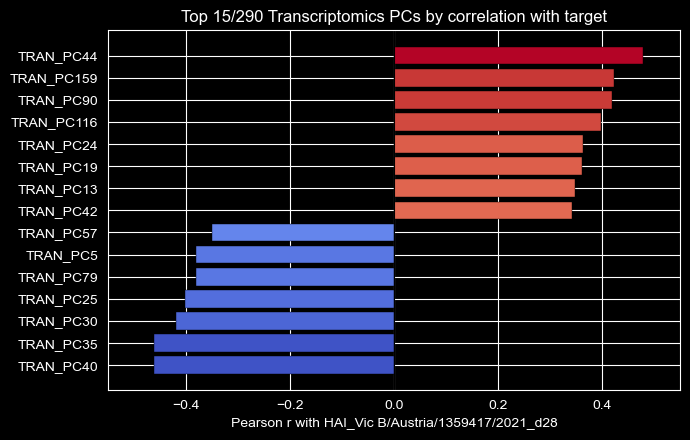

In [13]:
num_to_show = 15
tran_corrs = df_tran[tran_cols + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
top = tran_corrs.loc[tran_corrs.abs().sort_values(ascending=False).head(num_to_show).index]
top = top.sort_values()  # ascending so largest positive lands at top of barh

vmax = top.abs().max()
colors = plt.cm.coolwarm((top.values / vmax + 1) / 2)

fig, ax = plt.subplots(figsize=(7, max(4, num_to_show * 0.3)))
ax.barh(top.index, top.values, color=colors, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(f'Pearson r with {TARGET_COL}')
ax.set_title(f'Top {num_to_show}/{len(tran_cols)} Transcriptomics PCs by correlation with target')
ax.set_xlim(-vmax * 1.15, vmax * 1.15)
plt.tight_layout()
plt.show()

### Drop sparse features

Drop columns missing in more than half the 920 rows — they're too gappy for models to learn from and they slow training enough that tree models time out (which is why the previous run produced only a GLM).

In [14]:
miss_frac = df.isna().mean()
sparse_cols = miss_frac[miss_frac > MISSING_THRESHOLD].index

if FORCE_KEEP_TRANSCRIPTOMICS:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL and c not in tran_cols]
else:
    cols_to_drop = [c for c in sparse_cols if c != TARGET_COL]

df = df.drop(columns=cols_to_drop)
print(f'Dropped {len(cols_to_drop)} columns with >{MISSING_THRESHOLD:.0%} missing.')
print(f'Shape: {df.shape}')

Dropped 0 columns with >80% missing.
Shape: (920, 343)


In [15]:
surviving_tran = [c for c in df.columns if c.startswith('TRAN_')]
print(f'TRAN columns surviving sparse filter: {len(surviving_tran)} / {len(tran_cols)}')

TRAN columns surviving sparse filter: 290 / 290


### Drop other-task target columns

The challenge participants only have baseline data (demographics + d0 + d7) — d28 and d365 measurements don't exist for them yet (those are what we're being asked to predict). If we leave other `_d28` / `_d365` columns in the feature set, the model will learn to lean on them during training, but at predict time they'll all be NaN for the challenge data. The columns happen to exist in our training parquet because they're targets for other tasks (4.1, 4.2, …, 4.10), but they aren't legitimate features for *any* task — drop them.

In [16]:
other_target_cols = [c for c in df.columns
                     if (c.endswith('_d28') and c != TARGET_COL) or c.endswith('_d365')]
df = df.drop(columns=other_target_cols)
print(f'Dropped {len(other_target_cols)} other-task target columns.')
print(f'Final shape: {df.shape}')

Dropped 31 other-task target columns.
Final shape: (920, 312)


In [17]:
# Force float64 on all remaining HAI feature columns to prevent H2O from mistyping
# sparsely-populated columns as categorical, which crashes predict() on the challenge set.
hai_feature_cols = [c for c in df.columns if c.startswith('HAI_') and c != TARGET_COL]
for c in hai_feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    if c in challenge_data.columns:
        challenge_data[c] = pd.to_numeric(challenge_data[c], errors='coerce')
print(f'Forced float64 on {len(hai_feature_cols)} HAI feature columns in training and challenge data.')

Forced float64 on 17 HAI feature columns in training and challenge data.


In [18]:
print(f'Final shape: {df.shape}')
print(f'Target ({TARGET_COL}) stats (log2):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')

Final shape: (920, 312)
Target (HAI_Vic B/Austria/1359417/2021_d28) stats (log2):
count    920.000000
mean       4.956711
std        2.137109
min        2.321928
25%        3.321928
50%        5.321928
75%        6.321928
max       12.321928
Name: HAI_Vic B/Austria/1359417/2021_d28, dtype: float64

dtype counts:
float64    309
str          3
Name: count, dtype: int64


---
## AutoML Setup

In [19]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; OpenJDK 64-Bit Server VM Temurin-25.0.2+10 (build 25.0.2+10-LTS, mixed mode, sharing)
  Starting server from C:\Users\User\anaconda3\envs\cmi-flu-prediction-challenge-capstone\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\User\AppData\Local\Temp\tmpc9vfrake
  JVM stdout: C:\Users\User\AppData\Local\Temp\tmpc9vfrake\h2o_User_started_from_python.out
  JVM stderr: C:\Users\User\AppData\Local\Temp\tmpc9vfrake\h2o_User_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,00 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,2 months and 15 days
H2O_cluster_name:,H2O_from_python_User_w4fqh1
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.41 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [20]:
hai_col_types = {c: 'real' for c in hai_feature_cols}
data = h2o.H2OFrame(df, column_types=hai_col_types)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (920, 312)


---
## AutoML Training

In [21]:
y = TARGET_COL
x = [c for c in data.columns if c not in (y, 'participant_id')]
print(f'Training samples: {data.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(
    max_models=10,
    seed=1,
    nfolds=5,
    keep_cross_validation_predictions=True,
    max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS
)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=data)
print('Training complete.')

Training samples: 920  |  Features: 310
Training complete.


In [22]:
lb_df = aml.leaderboard.as_data_frame(use_multi_thread=True)
lb_df

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_BestOfFamily_1_AutoML_1_202605...,1.476165,2.179063,1.068295,0.254472,2.179063
1,StackedEnsemble_AllModels_1_AutoML_1_20260527_...,1.478132,2.184874,1.073130,0.254450,2.184874
2,XRT_1_AutoML_1_20260527_205239,1.506120,2.268396,1.125331,0.260997,2.268396
3,GBM_3_AutoML_1_20260527_205239,1.508399,2.275269,1.092246,0.258941,2.275269
4,GBM_4_AutoML_1_20260527_205239,1.514141,2.292624,1.105241,0.261383,2.292624
5,DRF_1_AutoML_1_20260527_205239,1.514531,2.293805,1.122002,0.261992,2.293805
6,GBM_2_AutoML_1_20260527_205239,1.516536,2.299882,1.115625,0.261118,2.299882
7,GBM_grid_1_AutoML_1_20260527_205239_model_1,1.517051,2.301445,1.119166,0.260562,2.301445
8,GBM_1_AutoML_1_20260527_205239,1.522811,2.318953,1.134318,0.259477,2.318953
9,GLM_1_AutoML_1_20260527_205239,1.529406,2.339082,1.130148,0.265537,2.339082


In [23]:
# Best overall (may be a StackedEnsemble) — used for predictions and saved as the deliverable
top_model = h2o.get_model(lb_df['model_id'].iloc[0])

# Best non-ensemble — used for Spearman CV and varimp, since StackedEnsembles don't expose
# cross-validation holdout predictions in the same way base models do.
top_base_model_id = lb_df[~lb_df['model_id'].str.contains('StackedEnsemble')]['model_id'].iloc[0]
top_base_model = h2o.get_model(top_base_model_id)

cv_preds = top_base_model.cross_validation_holdout_predictions().as_data_frame(use_multi_thread=True)['predict']
actuals = data[y].as_data_frame(use_multi_thread=True)[y]

rho, pval = spearmanr(actuals, cv_preds)
print(f'Prediction model:  {top_model.model_id}')
print(f'Scoring model:     {top_base_model.model_id}')
print(f'Task 4.3 — Spearman (best base model 5-fold CV): {rho:.3f}  (p={pval:.4f})')

Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%
Prediction model:  StackedEnsemble_BestOfFamily_1_AutoML_1_20260527_205239
Scoring model:     XRT_1_AutoML_1_20260527_205239
Task 4.3 — Spearman (best base model 5-fold CV): 0.721  (p=0.0000)


Best base model: XRT_1_AutoML_1_20260527_205239


,variable,relative_importance,scaled_importance,percentage
0,HAI_Vic B/Austria/1359417/2021_d0,38532.667969,1.000000,0.439134
1,HAI_H3N2 A/Hong Kong/4801/2014_d0,6723.011230,0.174476,0.076618
2,PART_age,5428.095215,0.140870,0.061861
3,HAI_H3N2 A/Tasmania/503/2020_d0,2908.331543,0.075477,0.033145
4,HAI_Vic B/Washington/2/2019_d0,2759.968018,0.071627,0.031454
5,HAI_Yam B/Phuket/3073/2013_d0,2669.678223,0.069284,0.030425
6,HAI_Vic B/Colorado/6/2017_d0,2593.336670,0.067302,0.029555
7,HAI_H1N1 A/California/7/2009_d0,2315.407959,0.060089,0.026387
8,HAI_H1N1 A/Victoria/4897/2022_d0,2269.268555,0.058892,0.025862
9,HAI_H1N1 A/Michigan/45/2015_d0,2080.923584,0.054004,0.023715


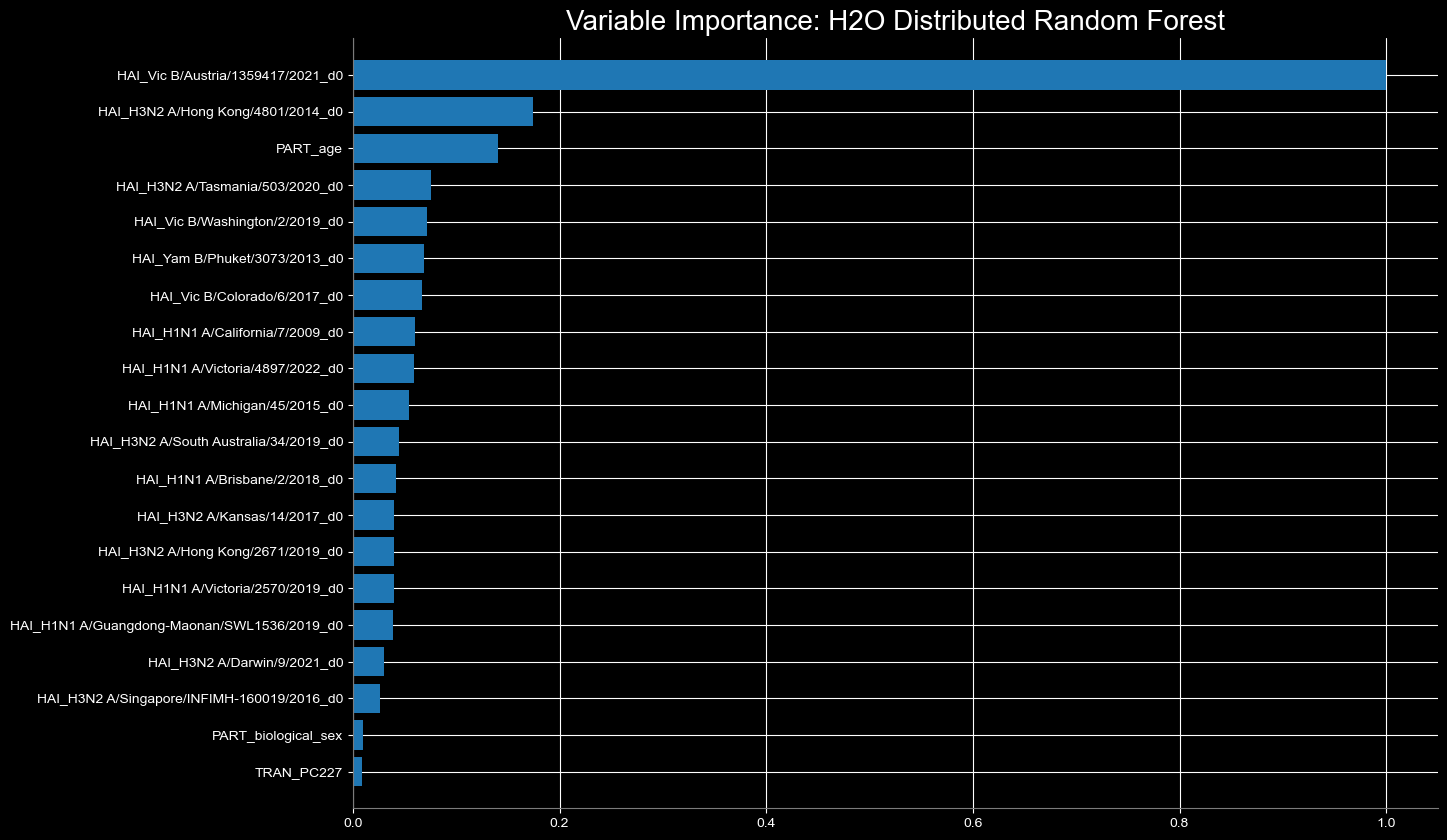

<Figure size 640x480 with 0 Axes>

In [24]:
print(f'Best base model: {top_base_model.model_id}')
varimp = top_base_model.varimp(use_pandas=True)
display(varimp.head(20))
top_base_model.varimp_plot(num_of_features=20)

In [25]:
challenge_col_types = {c: 'real' for c in hai_feature_cols if c in challenge_data.columns}
challenge_hf = h2o.H2OFrame(challenge_data, column_types=challenge_col_types)
y_pred = top_model.predict(challenge_hf).as_data_frame(use_multi_thread=True)['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.3': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_3.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Export File progress: |██████████████████████████████████████████████████████████| (done) 100%


,Participant_ID,Task_4.3
0,2024_UGA.ID_077,38.495267
1,2024_UGA.ID_086,137.654236
2,2024_UGA.ID_128,25.513240
3,2024_UGA.ID_170,26.675485
4,2024_UGA.ID_179,86.069773
5,2024_UGA.ID_215,48.170278
6,2024_UGA.ID_219,57.113504
7,2024_UGA.ID_275,37.821883
8,2024_UGA.ID_295,342.492975
9,2024_UGA.ID_296,41.547024


In [26]:
model_path = h2o.save_model(model=top_model, path='.', filename='models/model_4.3', force=True)
print(f'Model saved to: {model_path}')

Model saved to: C:\Users\User\repos\cmi-flu-prediction-challenge-capstone\automl_models\models\model_4.3


In [27]:
h2o.cluster().shutdown()

H2O session _sid_91a1 closed.


---
## Conclusion

- **Leader model:** StackedEnsemble_BestOfFamily (used for challenge predictions)
- **Scoring model:** XRT_1 (best non-ensemble base, used for CV Spearman)
- **CV Spearman:** 0.721 (p < 0.0001)
- **Training samples:** 920 | **Features:** 310
- **Model saved:** `automl_models/model_4.3`

**Target:** log2 HAI titer for Vic B/Austria/1359417/2021 at D28. The pre-vaccination titer for the same strain (`HAI_Vic B/Austria/1359417/2021_d0`) is the dominant predictor. Challenge predictions span roughly [9, 342] in raw titer space after `np.exp2`.

**Feature set:** 3 demographics + 17 HAI d0/d7 columns + 290 TRAN columns, after dropping columns >80% missing and all d28/d365 leakage columns. `FORCE_KEEP_TRANSCRIPTOMICS = True` preserves all 290 TRAN PCs even though only ~5.2% of the 920 training rows have transcriptomics data.

**Imputation note:** No manual imputation is applied. H2O's tree models (GBM, XRT, DRF) handle `NaN` natively at each split during training and prediction, including inside CV folds — eliminating any leakage that would arise from pre-computing medians on the full training set.

Submission saved to `automl_submission/task_4_3.csv` (raw titer scale via `np.exp2`).

To reload the model: `h2o.load_model('automl_models/model_4.3')`